In [130]:
import pandas as pd


In [131]:
df = pd.read_csv("/content/drive/MyDrive/Project ML /moive/IMDB Dataset.csv")

In [132]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [133]:
df.columns

Index(['review', 'sentiment'], dtype='object')

### Step 1: Basic Dataset Understanding

In [134]:
# Check the shape of the dataset
df.shape

(50000, 2)

In [135]:
# Check basic information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [136]:
# Check for missing values
df.isnull().sum()

,0
review,0
sentiment,0


In [137]:
# Check the distribution of sentiment
df['sentiment'].value_counts()

,count
sentiment,
positive,25000
negative,25000


In [138]:
# Check the percentage distribution
df['sentiment'].value_counts(normalize=True) * 100

,proportion
sentiment,
positive,50.0
negative,50.0


In [139]:
df.duplicated().sum()

np.int64(418)

In [140]:
df = df.drop_duplicates()

In [141]:
# check the df shape after removing the duplicate rows
df.shape

(49582, 2)

In [142]:
df.duplicated().sum()

np.int64(0)

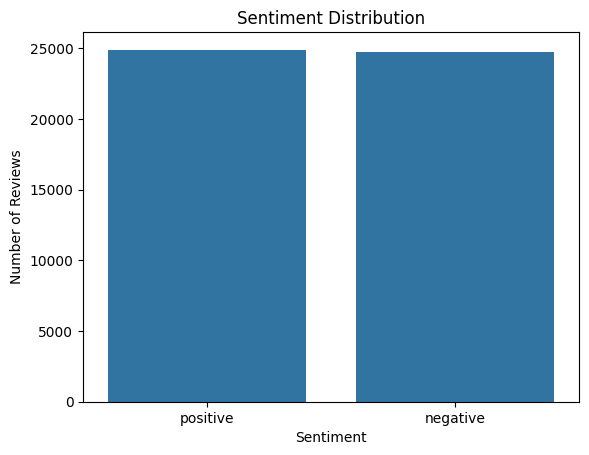

In [143]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x='sentiment')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

### The dataset is nearly balanced between positive and negative sentiments, with no missing values. During data cleaning, 418 duplicate records were identified and removed.

In [144]:
df['review_length'] = df['review'].str.len()

In [145]:
df['review_length'].describe()

,review_length
count,49582.000000
mean,1310.568230
std,990.762238
min,32.000000
25%,699.000000
50%,971.000000
75%,1592.000000
max,13704.000000


In [146]:
df['word_count'] = df['review'].str.split().str.len()

In [147]:
df['word_count'].describe()

,word_count
count,49582.000000
mean,231.350167
std,171.542020
min,4.000000
25%,126.000000
50%,173.000000
75%,281.000000
max,2470.000000


In [148]:
## compare review length by sentiment
df.groupby('sentiment')['word_count'].describe()

,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
negative,24698.0,229.596607,165.103430,4.0,128.0,174.0,278.0,1522.0
positive,24884.0,233.090620,177.688169,10.0,125.0,172.0,284.0,2470.0


## Preprocessing

In [149]:
### removing HTML tags
import re

def clean_html(text):
    return re.sub(r'<br\s*/?>', ' ', text)

In [150]:
print(df['review'].iloc[1])
print("\n--- CLEANED ---\n")
print(clean_html(df['review'].iloc[1]))

A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only "has got all the polari" but he has all the voices down pat too! You can truly see the seamless editing guided by the references to Williams' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. A masterful production about one of the great master's of comedy and his life. <br /><br />The realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional 'dream' techniques remains solid then disappears. It plays on our knowledge and our senses, particularly with the scenes concerning Orton and Halliwell and the sets (particularly of their flat with Halliwell's murals decorating every surface) are terribly well done.



In [151]:
### Applying the HTML cleaning to the entire dataset
df['clean_review'] = df['review'].apply(clean_html)

In [152]:
df[['review', 'clean_review']].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,One of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,A wonderful little production. The filming t...
2,I thought this was a wonderful way to spend ti...,I thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,Basically there's a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...","Petter Mattei's ""Love in the Time of Money"" is..."


In [153]:
### lowercasing
df['clean_review'] = df['clean_review'].str.lower()

In [154]:
# checking
print(df['clean_review'].iloc[1])

a wonderful little production.   the filming technique is very unassuming- very old-time-bbc fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece.   the actors are extremely well chosen- michael sheen not only "has got all the polari" but he has all the voices down pat too! you can truly see the seamless editing guided by the references to williams' diary entries, not only is it well worth the watching but it is a terrificly written and performed piece. a masterful production about one of the great master's of comedy and his life.   the realism really comes home with the little things: the fantasy of the guard which, rather than use the traditional 'dream' techniques remains solid then disappears. it plays on our knowledge and our senses, particularly with the scenes concerning orton and halliwell and the sets (particularly of their flat with halliwell's murals decorating every surface) are terribly well done.


In [155]:
### removing unnecessary special characters
import re

def clean_text(text):
    text = re.sub(r"[^a-zA-Z0-9\s']", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [156]:
df['clean_review'] = df['clean_review'].apply(clean_text)

In [157]:
## check
print(df['clean_review'].iloc[1])

a wonderful little production the filming technique is very unassuming very old time bbc fashion and gives a comforting and sometimes discomforting sense of realism to the entire piece the actors are extremely well chosen michael sheen not only has got all the polari but he has all the voices down pat too you can truly see the seamless editing guided by the references to williams' diary entries not only is it well worth the watching but it is a terrificly written and performed piece a masterful production about one of the great master's of comedy and his life the realism really comes home with the little things the fantasy of the guard which rather than use the traditional 'dream' techniques remains solid then disappears it plays on our knowledge and our senses particularly with the scenes concerning orton and halliwell and the sets particularly of their flat with halliwell's murals decorating every surface are terribly well done


### train test split

In [158]:
from sklearn.model_selection import train_test_split

In [159]:
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_review'],
    df['sentiment'],
    test_size=0.20,
    random_state=42,
    stratify=df['sentiment']
)

### Convert Text into Numerical Features using TF-IDF

In [160]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [161]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

In [162]:
X_train_tfidf = tfidf.fit_transform(X_train)

In [163]:
X_test_tfidf = tfidf.transform(X_test)

In [164]:
print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

Training shape: (39665, 10000)
Testing shape: (9917, 10000)


In [165]:
y = df['sentiment']

In [166]:
## check the shape
print("TF-IDF Shape:", X.shape)

TF-IDF Shape: (39665, 10000)


## Training ML model

In [167]:
## Logistic regression
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)
model.fit(X_train_tfidf, y_train)
y_pred = model.predict(X_test_tfidf)
y_prob = model.predict_proba(X_test_tfidf)[:, 1]

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.9013814661692044
              precision    recall  f1-score   support

    negative       0.91      0.89      0.90      4940
    positive       0.89      0.92      0.90      4977

    accuracy                           0.90      9917
   macro avg       0.90      0.90      0.90      9917
weighted avg       0.90      0.90      0.90      9917

Confusion Matrix:
[[4385  555]
 [ 423 4554]]
ROC-AUC: 0.9638613736548446


In [168]:
##  Navie bayes
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Create Naive Bayes model
nb_model = MultinomialNB()

# Train the model
nb_model.fit(X_train_tfidf, y_train)

# Predictions
nb_pred = nb_model.predict(X_test_tfidf)

# Prediction probabilities
nb_prob = nb_model.predict_proba(X_test_tfidf)[:, 1]

# Evaluation
nb_accuracy = accuracy_score(y_test, nb_pred)
nb_auc = roc_auc_score(y_test, nb_prob)

print("========== Naive Bayes Results ==========")
print(f"Accuracy: {nb_accuracy:.4f}")
print(f"ROC-AUC: {nb_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, nb_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, nb_pred))

========== Naive Bayes Results ==========
Accuracy: 0.8677
ROC-AUC: 0.9413

Classification Report:
              precision    recall  f1-score   support

    negative       0.88      0.85      0.87      4940
    positive       0.86      0.88      0.87      4977

    accuracy                           0.87      9917
   macro avg       0.87      0.87      0.87      9917
weighted avg       0.87      0.87      0.87      9917


Confusion Matrix:
[[4212  728]
 [ 584 4393]]


In [169]:
## Linear SVM
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Create Linear SVM model
svm_model = LinearSVC(
    C=1.0,
    random_state=42
)

# Train the model
svm_model.fit(X_train_tfidf, y_train)

# Predictions
svm_pred = svm_model.predict(X_test_tfidf)

# Evaluation
svm_accuracy = accuracy_score(y_test, svm_pred)

print("========== Linear SVM Results ==========")
print(f"Accuracy: {svm_accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, svm_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, svm_pred))

========== Linear SVM Results ==========
Accuracy: 0.8959

Classification Report:
              precision    recall  f1-score   support

    negative       0.90      0.89      0.89      4940
    positive       0.89      0.90      0.90      4977

    accuracy                           0.90      9917
   macro avg       0.90      0.90      0.90      9917
weighted avg       0.90      0.90      0.90      9917


Confusion Matrix:
[[4392  548]
 [ 484 4493]]


## Selecting logistic regression because it performs the  best

In [170]:
## improving logistic regression
from sklearn.linear_model import LogisticRegression

final_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

final_model.fit(X_train_tfidf, y_train)

final_pred = final_model.predict(X_test_tfidf)
final_prob = final_model.predict_proba(X_test_tfidf)[:, 1]

print("Final Model: Logistic Regression")
print(f"Accuracy: {accuracy_score(y_test, final_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, final_prob):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, final_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, final_pred))

Final Model: Logistic Regression
Accuracy: 0.9014
ROC-AUC: 0.9639

Classification Report:
              precision    recall  f1-score   support

    negative       0.91      0.89      0.90      4940
    positive       0.89      0.92      0.90      4977

    accuracy                           0.90      9917
   macro avg       0.90      0.90      0.90      9917
weighted avg       0.90      0.90      0.90      9917


Confusion Matrix:
[[4385  555]
 [ 423 4554]]


In [171]:
## Test a Completely New Review
review = "This movie was absolutely amazing and I really enjoyed it!"

review_tfidf = loaded_tfidf.transform([review])

prediction = loaded_model.predict(review_tfidf)[0]
probability = loaded_model.predict_proba(review_tfidf)[0]

print("Prediction:", prediction)
print("Probability:", probability)

Prediction: positive
Probability: [0.03596595 0.96403405]


In [172]:
## Save the TF-IDF Vectorizer + Final Model
import joblib
import joblib

# Save the final Logistic Regression model
joblib.dump(final_model, "sentiment_model.pkl")

# Save the TF-IDF vectorizer
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model and TF-IDF vectorizer saved successfully!")

Model and TF-IDF vectorizer saved successfully!


In [173]:
## Test Loading the Saved Files
import joblib

loaded_model = joblib.load("sentiment_model.pkl")
loaded_tfidf = joblib.load("tfidf_vectorizer.pkl")

print("Model loaded:", type(loaded_model).__name__)
print("Vectorizer loaded:", type(loaded_tfidf).__name__)

Model loaded: LogisticRegression
Vectorizer loaded: TfidfVectorizer
